In [1]:
import numpy as np
import tensorflow as tf
import seaborn as sns
import matplotlib.pyplot as plt
import cv2
import os
from tensorflow import keras
import glob as gb
import pandas as pd
from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras.layers import RandomFlip, RandomRotation
from tensorflow.keras.layers import Dense, Dropout, Flatten, Input
from tensorflow.keras.layers import Conv2D, MaxPool2D ,LeakyReLU
from sklearn.model_selection import train_test_split

In [2]:
IMG_SIZE = (224, 224) # resolution
directory = "Crop___Disease/Rice"
BATCH_SIZE = 32
num_class = 4
VALIDATION_SPLIT = 0.1  #   10% validation split
TEST_SPLIT = 0.1
train_dataset = image_dataset_from_directory(directory,
                                             shuffle=True,
                                             labels='inferred',
                                             batch_size=BATCH_SIZE,
                                             image_size=IMG_SIZE,

                                             validation_split=VALIDATION_SPLIT + TEST_SPLIT,
                                             subset='training',
                                             color_mode='rgb',
                                             seed=42)
corn_validation_dataset = image_dataset_from_directory(directory,
                                             shuffle=True,
                                             labels='inferred',
                                             batch_size=BATCH_SIZE,
                                             image_size=IMG_SIZE,

                                             validation_split=VALIDATION_SPLIT + TEST_SPLIT,
                                             subset='validation',
                                             color_mode='rgb',
                                             seed=42)
# validation and test split proportions
num_val_samples = int((VALIDATION_SPLIT / (VALIDATION_SPLIT + TEST_SPLIT)) * corn_validation_dataset.cardinality().numpy())
validation_dataset = corn_validation_dataset.take(num_val_samples)
test_dataset = corn_validation_dataset.skip(num_val_samples)

print(f"Training dataset size: {len(train_dataset)} batches")
print(f"Validation dataset size: {len(validation_dataset)} batches")
print(f"Test dataset size: {len(test_dataset)} batches")

Found 2791 files belonging to 4 classes.
Using 2233 files for training.
Found 2791 files belonging to 4 classes.
Using 558 files for validation.
Training dataset size: 70 batches
Validation dataset size: 9 batches
Test dataset size: 9 batches


In [3]:
class_names = train_dataset.class_names
class_names

['Rice___Brown_Spot', 'Rice___Healthy', 'Rice___Hispa', 'Rice___Leaf_Blast']

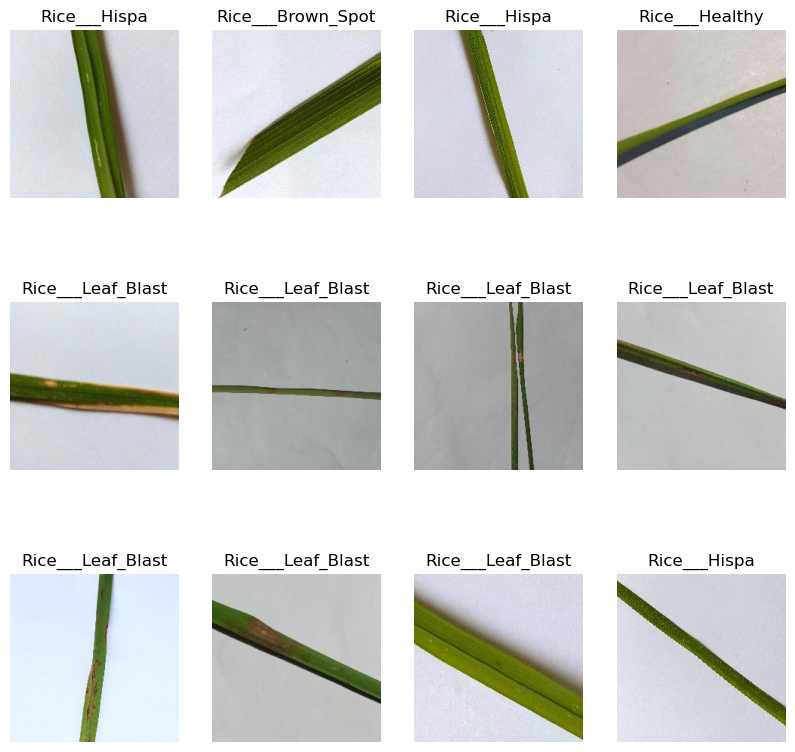

In [4]:
plt.figure(figsize=(10, 10))
for image_batch, labels_batch in train_dataset.take(1):
    for i in range(12):
        ax = plt.subplot(3, 4, i + 1)
        plt.imshow(image_batch[i].numpy().astype("uint8"))
        plt.title(class_names[labels_batch[i]])
        plt.axis("off")

C:\Users\NAHID\AppData\Local\Temp\ipykernel_4064\2436110488.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=folder_names, y=Data_imbalance, palette="rocket")


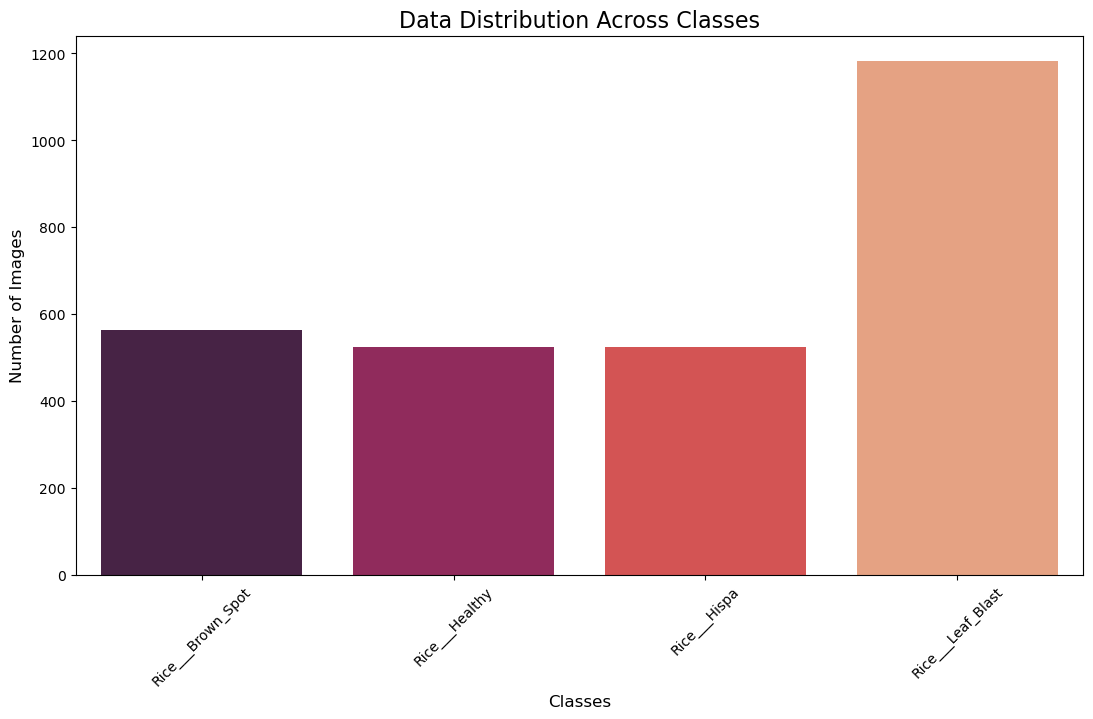

In [5]:
Data_imbalance = []
folder_names = []

# Iterate through each folder in the directory
for folder in os.listdir(directory):
    folder_path = os.path.join(directory, folder)
    if os.path.isdir(folder_path):  # Ensure it's a folder
        files = gb.glob(pathname=str(folder_path + "/*.*"))
        Data_imbalance.append(len(files))
        folder_names.append(folder)  # Collect folder names dynamically

# Plot the barplot with dynamic names
plt.figure(figsize=(13, 7))
sns.barplot(x=folder_names, y=Data_imbalance, palette="rocket")
plt.title("Data Distribution Across Classes", fontsize=16)
plt.xlabel("Classes", fontsize=12)
plt.ylabel("Number of Images", fontsize=12)
plt.xticks(rotation=45)  # Rotate x-axis labels if they are long
plt.show()

In [6]:
total = 0
for i in range(0,len(Data_imbalance)) :
    total +=Data_imbalance[i]

weight_for_0 = (1 / Data_imbalance[0]) * (total / 4.0)
weight_for_1 = (1 / Data_imbalance[1]) * (total / 4.0)
weight_for_2 = (1 / Data_imbalance[2]) * (total / 4.0)
weight_for_3 = (1 / Data_imbalance[3]) * (total / 4.0)

class_weight = {0: weight_for_0, 1: weight_for_1, 2: weight_for_2, 3: weight_for_3}

print('Weight for class 0: {:.2f}'.format(weight_for_0))
print('Weight for class 1: {:.2f}'.format(weight_for_1))
print('Weight for class 2: {:.2f}'.format(weight_for_2))
print('Weight for class 3: {:.2f}'.format(weight_for_3))

Weight for class 0: 1.24
Weight for class 1: 1.33
Weight for class 2: 1.33
Weight for class 3: 0.59


In [7]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.2, fill_mode='reflect'),
    tf.keras.layers.RandomZoom(0.2, fill_mode='reflect'),
    tf.keras.layers.RandomHeight(0.2),
    tf.keras.layers.RandomWidth(0.2)
])

In [8]:
import logging

# Set the logging level to suppress warnings
logging.getLogger('tensorflow').setLevel(logging.ERROR)

In [9]:
# Define mean and std for normalization
mean = tf.constant([0.485, 0.456, 0.406])  # ImageNet mean for R, G, B
std = tf.constant([0.229, 0.224, 0.225])   # ImageNet std for R, G, B

# Function to normalize after rescaling
def normalize_image(image, label):
    # Rescale image to [0, 1]
    image = tf.cast(image, tf.float32) / 255.0
    # Normalize image
    image = (image - mean) / std
    return image, label

# Apply normalization to the augmented dataset
train_dataset = train_dataset.map(normalize_image, num_parallel_calls=tf.data.AUTOTUNE)
validation_dataset = validation_dataset.map(normalize_image, num_parallel_calls=tf.data.AUTOTUNE)
test_dataset = test_dataset.map(normalize_image, num_parallel_calls=tf.data.AUTOTUNE)

In [16]:
from tensorflow.keras import layers, models, Model
from tensorflow.keras.optimizers import Adam

In [11]:
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import classification_report

In [12]:
from sklearn.metrics import confusion_matrix

In [13]:
import tensorflow_hub as hub
import kagglehub

In [17]:
IMG_SHAPE = IMG_SIZE +(3,)
# Load DeiT model
deit_path = kagglehub.model_download("spsayakpaul/deit/tensorFlow2/base-distilled-patch16-224")
deit_base = hub.KerasLayer(deit_path, trainable=False)

# Load DenseNet201 model
densenet201_base = tf.keras.applications.DenseNet201(
    weights='imagenet',                          
    input_shape=IMG_SHAPE,                 
    include_top=False                            
)
densenet201_base.trainable = False

# Define input layer
inp = layers.Input(shape=IMG_SHAPE)

# Apply data augmentation
x = data_augmentation(inp)
x = layers.Resizing(224, 224)(x)

# Preprocess for DenseNet (normalization for ImageNet)
densenet_preprocessed = tf.keras.applications.densenet.preprocess_input(x)

# Get features from both models
deit_features = deit_base(x, training=True)
if isinstance(deit_features, tuple):
    deit_features = deit_features[0]

densenet_features = densenet201_base(densenet_preprocessed)

# Process DenseNet features
densenet_features = layers.GlobalAveragePooling2D()(densenet_features)

# Concatenate features from both models
combined = layers.Concatenate()([deit_features, densenet_features])

# Add classifier head
x = layers.Dropout(0.5)(combined)
x = layers.Dense(128, activation='gelu')(x)
x = layers.Dropout(0.5)(x)
output = layers.Dense(num_class, activation='softmax')(x)

# Create hybrid model
hybrid_model = Model(inputs=inp, outputs=output)

# Compile the model
hybrid_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

# Display model architecture
hybrid_model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_4 (InputLayer)           [(None, 224, 224, 3  0           []                               
                                )]                                                                
                                                                                                  
 sequential (Sequential)        (None, 224, 224, 3)  0           ['input_4[0][0]']                
                                                                                                  
 resizing_1 (Resizing)          (None, 224, 224, 3)  0           ['sequential[1][0]']             
                                                                                                  
 tf.math.truediv_2 (TFOpLambda)  (None, 224, 224, 3)  0          ['resizing_1[0][0]']         

In [18]:
print("Training Hybrid Model...")
hybrid_history = hybrid_model.fit(
    train_dataset,
    class_weight=class_weight,
    validation_data=validation_dataset,
    epochs=10
)

Training Hybrid Model...
Epoch 1/10
70/70 [==============================] - 94s 1s/step - loss: 1.4676 - accuracy: 0.4563 - val_loss: 1.0298 - val_accuracy: 0.5486
Epoch 2/10
70/70 [==============================] - 87s 1s/step - loss: 1.0801 - accuracy: 0.5464 - val_loss: 1.0547 - val_accuracy: 0.5625
Epoch 3/10
70/70 [==============================] - 88s 1s/step - loss: 1.0209 - accuracy: 0.5678 - val_loss: 0.9567 - val_accuracy: 0.5764
Epoch 4/10
70/70 [==============================] - 87s 1s/step - loss: 0.9799 - accuracy: 0.5889 - val_loss: 1.0452 - val_accuracy: 0.5243
Epoch 5/10
70/70 [==============================] - 87s 1s/step - loss: 0.9679 - accuracy: 0.5844 - val_loss: 0.9188 - val_accuracy: 0.5972
Epoch 6/10
70/70 [==============================] - 86s 1s/step - loss: 0.9548 - accuracy: 0.5925 - val_loss: 0.8992 - val_accuracy: 0.5451
Epoch 7/10
70/70 [==============================] - 87s 1s/step - loss: 0.9108 - accuracy: 0.6108 - val_loss: 0.8790 - val_accuracy: 0.

In [19]:
print(f"Test dataset type: {type(test_dataset)}")  

for image, label in test_dataset.take(1):
    print(f"Sample image shape: {image.shape}, Sample label shape: {label.shape}")

# Initialize empty lists to store true labels and predicted labels
y_true = []
y_pred_classes = []

# Iterate through the test dataset to collect the true labels and predictions
for images, labels in test_dataset:
    # Collect true labels (convert to numpy array)
    y_true.extend(labels.numpy())
    
    # Make predictions using the model
    y_pred_prob = hybrid_model(images, training=False)  # Model predictions (probabilities)
    
    # Convert predicted probabilities to class labels (argmax along the class axis)
    y_pred_classes.extend(tf.argmax(y_pred_prob, axis=1).numpy())

# Convert y_true and y_pred_classes to NumPy arrays for compatibility with sklearn
y_true = np.array(y_true)
y_pred_classes = np.array(y_pred_classes)

# Ensure the shape of the true and predicted labels are consistent
print(f"Shape of y_true: {y_true.shape}")
print(f"Shape of y_pred_classes: {y_pred_classes.shape}")

# Now, you can compute the precision, recall, and f1-score
precision = precision_score(y_true, y_pred_classes, average='weighted')
recall = recall_score(y_true, y_pred_classes, average='weighted')
f1 = f1_score(y_true, y_pred_classes, average='weighted')
# Evaluate the model on the test dataset
test_loss, test_accuracy = hybrid_model.evaluate(test_dataset)

# Print the results
print(f"Test Loss: {test_loss}")
print(f"Test Accuracy: {test_accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1-Score: {f1}")

Test dataset type: <class 'tensorflow.python.data.ops.dataset_ops.ParallelMapDataset'>
Sample image shape: (32, 224, 224, 3), Sample label shape: (32,)
Shape of y_true: (270,)
Shape of y_pred_classes: (270,)
9/9 [==============================] - 6s 269ms/step - loss: 0.9222 - accuracy: 0.5556
Test Loss: 0.9221533536911011
Test Accuracy: 0.5555555820465088
Precision: 0.6635988763889465
Recall: 0.5444444444444444
F1-Score: 0.5368195099214523


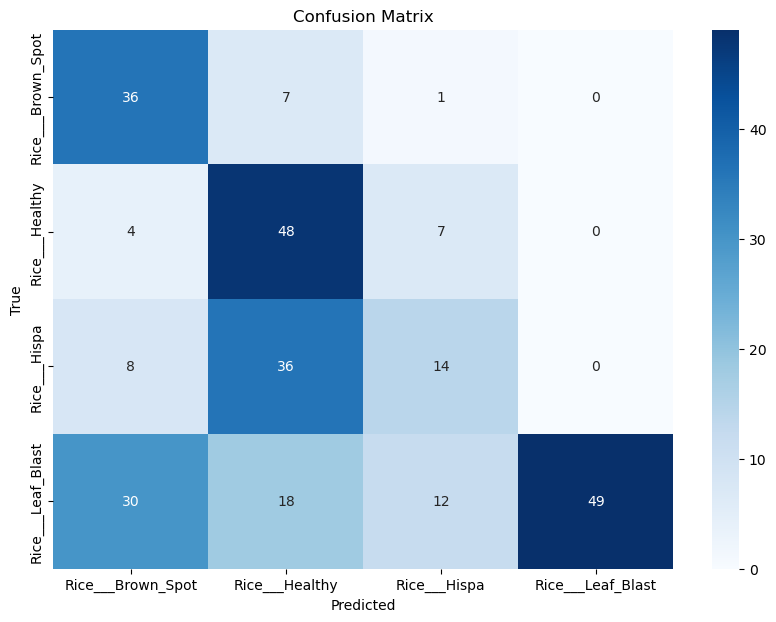

In [20]:
# Compute the confusion matrix
cm = confusion_matrix(y_true, y_pred_classes)

# Plot the confusion matrix
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

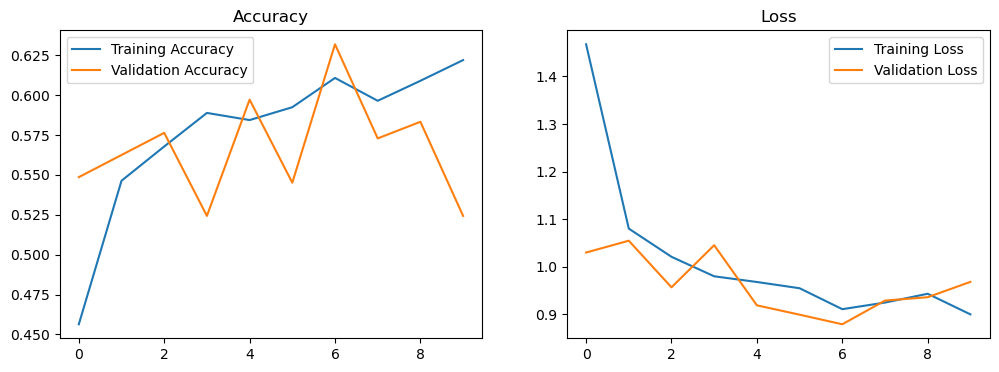

In [21]:
#Graph
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(hybrid_history.history['accuracy'], label='Training Accuracy')
plt.plot(hybrid_history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(hybrid_history.history['loss'], label='Training Loss')
plt.plot(hybrid_history.history['val_loss'], label='Validation Loss')
plt.title('Loss')
plt.legend()

plt.show()

In [22]:
hybrid_model.save("rice_densenet_deit_hybrid_model", save_format="tf")